# Projeto Prático: Análise Exploratória de Dados
**Tema:** Perfil Estatístico dos Jogadores da Seleção Brasileira (Ciclo Copa 2026)
**Grupo 9**

---

## 1. Entendimento do Problema e Contexto
O objetivo deste projeto é analisar estatisticamente o desempenho dos jogadores cotados para representar o Brasil na Copa do Mundo de 2026. Utilizando medidas de centralização, dispersão e correlação, buscaremos entender o padrão numérico (jogos, gols, assistências) que define um jogador de nível de Seleção.

---

## 2. Importação de Bibliotecas e Configuração

In [1]:
# Bibliotecas de manipulação de dados
import pandas as pd
import numpy as np

# Bibliotecas de visualização gráfica
import matplotlib.pyplot as plt
import seaborn as sns

# Configurando o estilo padrão dos gráficos para ficarem mais bonitos
sns.set_theme(style="whitegrid")

# Define o tamanho padrão dos gráficos
plt.rcParams['figure.figsize'] = (10, 6) 

---
## 3. Leitura e Limpeza dos Dados
Nesta etapa, faremos o carregamento do arquivo CSV contendo os dados primários coletados pelo grupo e a verificação inicial das colunas.

In [2]:
# Lendo o arquivo Excel DIRETAMENTE da pasta 'data'
dfs = pd.read_excel("Dataset.xlsx", sheet_name=None)

# Separando as abas da planilha em variáveis diferentes
df_todos = dfs['Todos']
df_zagueiro = dfs['Zagueiro']
df_meio = dfs['Meio-Campo']
df_atacantes = dfs['Atacantes']
df_goleiros = dfs['Goleiros']

# 1.1- Identificação e tratamento de colunas vazias
for nome in dfs:
    dfs[nome] = dfs[nome].loc[:, ~dfs[nome].columns.str.contains('^Unnamed')]

# 1.2- Identificação de dados duplicados
for nome, df in dfs.items():
    print(f"{nome}: {df.duplicated().sum()} duplicados encontrados")

# Exibindo as 5 primeiras linhas da aba 'Todos' para confirmar o sucesso!
display(df_todos.head())

Todos: 0 duplicados encontrados
Zagueiro: 0 duplicados encontrados
Meio-Campo: 0 duplicados encontrados
Atacantes: 0 duplicados encontrados
Goleiros: 0 duplicados encontrados


,Jogador,Posição,Idade,Perna boa,Clube
0,Endrick,Atacante,19,Canhoto,Lyon
1,G. Martinelli,Atacante,24,Destro,Arsenal
2,Igor Thiago,Atacante,24,Destro,Brentford
3,João Pedro,Atacante,24,Destro,Chelsea
4,Luiz henrique,Atacante,25,Canhoto,Zenit


### 3.1 Como definir que um jogador é experiente?

Decidimos definir a experiência dos jogadores por meio de quantis em relação a quantidade de jogos que eles possuem na seleção. Visto que a diferença entre a média e o desvio padrão nas categorias: zagueiros e atacantes é muito alta, decidimos usar o percentil de 80% para delimitar que é experiente e inexperiente. Já nas demais, decimimos utilizar um percentil de 90%.

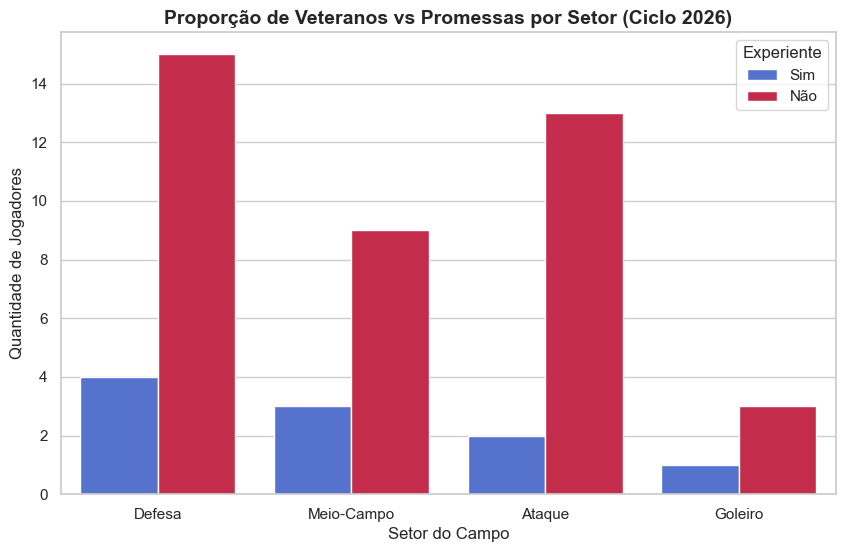

In [3]:
# Limpar nomes de colunas (remove espaços extras como 'Jogos ' ou ' Idade')
for nome, df in dfs.items():
    df.columns = df.columns.str.strip()

# ZAGUEIROS (Top 20%)
percentil_zag = df_zagueiro['Jogos na Seleção'].quantile(0.8)
df_zagueiro['Experiente'] = np.where(df_zagueiro['Jogos na Seleção'] > percentil_zag, 'Sim', 'Não')

# MEIO-CAMPISTAS (Top 20%)
percentil_meio = df_meio['Jogos na Seleção'].quantile(0.8)
df_meio['Experiente'] = np.where(df_meio['Jogos na Seleção'] > percentil_meio, 'Sim', 'Não')

# ATACANTES (Top 10%)
percentil_ata = df_atacantes['Jogos na Seleção'].quantile(0.9)
df_atacantes['Experiente'] = np.where(df_atacantes['Jogos na Seleção'] > percentil_ata, 'Sim', 'Não')

# GOLEIROS (Top 10%)
percentil_gol = df_goleiros['Jogos na Seleção'].quantile(0.9)
df_goleiros['Experiente'] = np.where(df_goleiros['Jogos na Seleção'] > percentil_gol, 'Sim', 'Não')

# === GRÁFICO: JOGADORES EXPERIENTES POR SETOR ===

# 1. Criando uma coluna temporária 'Setor' apenas para organizar o gráfico
df_zagueiro['Setor'] = 'Defesa'
df_meio['Setor'] = 'Meio-Campo'
df_atacantes['Setor'] = 'Ataque'
df_goleiros['Setor'] = 'Goleiro'

# 2. Juntando as informações de experiência em uma tabela única
df_experiencia = pd.concat([
    df_zagueiro[['Setor', 'Experiente']],
    df_meio[['Setor', 'Experiente']],
    df_atacantes[['Setor', 'Experiente']],
    df_goleiros[['Setor', 'Experiente']]
])

# 3. Configurando a figura
plt.figure(figsize=(10, 6))

# 4. Criando o gráfico de barras agrupadas
cores_personalizadas = {'Sim': 'royalblue', 'Não': 'crimson'}
sns.countplot(data=df_experiencia, x='Setor', hue='Experiente', palette=cores_personalizadas)

# 5. Adicionando os títulos e rótulos
plt.title('Proporção de Veteranos vs Promessas por Setor (Ciclo 2026)', fontsize=14, fontweight='bold')
plt.xlabel('Setor do Campo', fontsize=12)
plt.ylabel('Quantidade de Jogadores', fontsize=12)

# 6. Exibindo o gráfico
plt.show()

## 4. Análise Exploratória Inicial

--- Resumo Estatístico ---


,Idade
Quantidade,53.000000
Média idades,27.018868
Desvio Padrão,4.016747
Mínimo (idade),18.000000
1º Quartil (25%),24.000000
Mediana (50%),27.000000
3º Quartil (75%),30.000000
Máximo (idade),35.000000


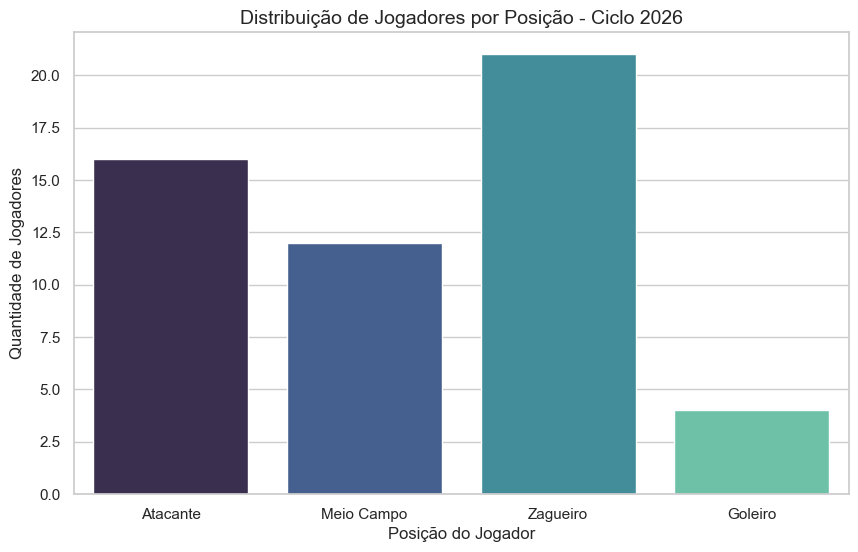

In [4]:
# 1. LIMPANDO OS DADOS: Removendo espaços invisíveis do começo e do final do texto
df_todos['Posição'] = df_todos['Posição'].str.strip()

# 2. Resumo Estatístico 
print("--- Resumo Estatístico ---")
resumo = df_todos.describe()

# Renomeia as linhas (índice) da tabela
resumo = resumo.rename(index={
    'count': 'Quantidade',
    'mean': 'Média idades',
    'std': 'Desvio Padrão',
    'min': 'Mínimo (idade)',
    '25%': '1º Quartil (25%)',
    '50%': 'Mediana (50%)',
    '75%': '3º Quartil (75%)',
    'max': 'Máximo (idade)'
})

# Exibe a tabela traduzida
display(resumo)

# 3. Criando o gráfico
sns.countplot(data=df_todos, x='Posição', hue='Posição', palette='mako')

plt.title('Distribuição de Jogadores por Posição - Ciclo 2026', fontsize=14)
plt.xlabel('Posição do Jogador')
plt.ylabel('Quantidade de Jogadores')

plt.show()

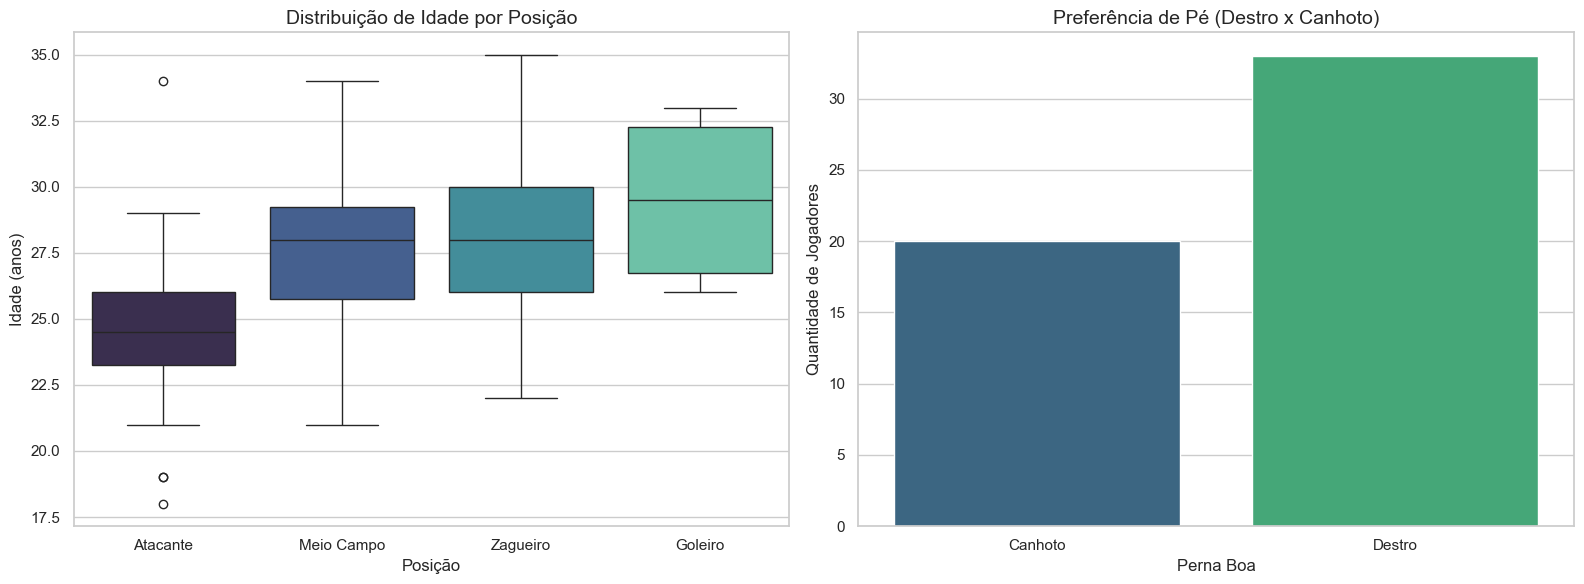

In [5]:
# Criando uma "tela" com 2 espaços lado a lado para os gráficos
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Boxplot de Idade por Posição (mostra a variação e a média)
sns.boxplot(data=df_todos, x='Posição', y='Idade', hue='Posição', palette='mako', ax=ax[0])
ax[0].set_title('Distribuição de Idade por Posição', fontsize=14)
ax[0].set_xlabel('Posição')
ax[0].set_ylabel('Idade (anos)')

# Gráfico 2: Quantidade de jogadores por Perna Boa
sns.countplot(data=df_todos, x='Perna boa', hue='Perna boa', palette='viridis', ax=ax[1])
ax[1].set_title('Preferência de Pé (Destro x Canhoto)', fontsize=14)
ax[1].set_xlabel('Perna Boa')
ax[1].set_ylabel('Quantidade de Jogadores')

# Ajusta o espaçamento para não ficar nada sobreposto e mostra na tela
plt.tight_layout()
plt.show()

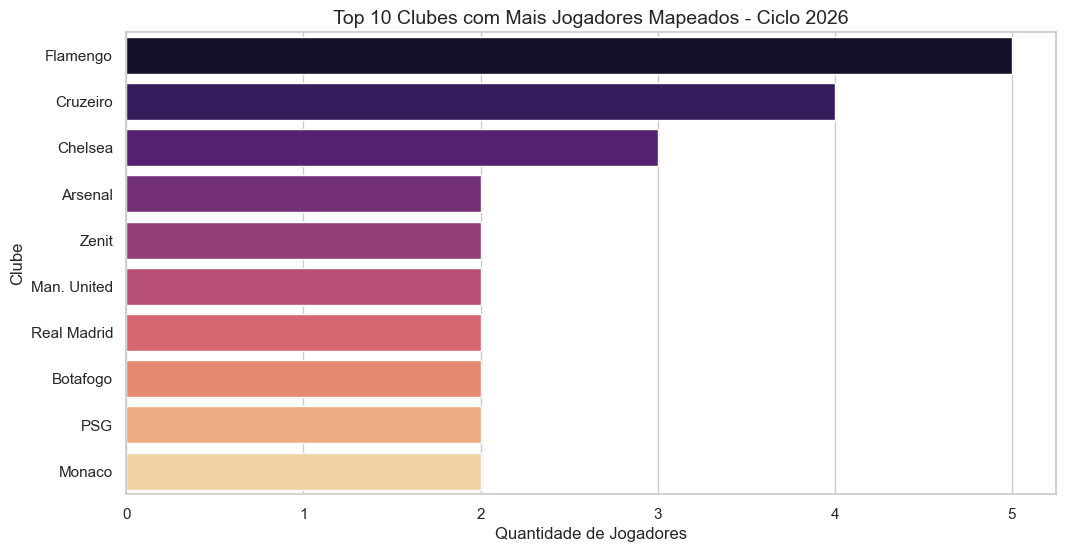

In [6]:
# Criando a figura com um tamanho legal
plt.figure(figsize=(12, 6))

# Contando os jogadores por clube e pegando apenas os 10 primeiros
top_clubes = df_todos['Clube'].value_counts().head(10)

# Criando um gráfico de barras horizontais
sns.barplot(x=top_clubes.values, y=top_clubes.index, hue=top_clubes.index, palette='magma', legend=False)

# Adicionando os títulos
plt.title('Top 10 Clubes com Mais Jogadores Mapeados - Ciclo 2026', fontsize=14)
plt.xlabel('Quantidade de Jogadores')
plt.ylabel('Clube')

# Exibindo o gráfico
plt.show()

In [7]:
# ===  Completando as Estatísticas ===
print("--- Medidas Adicionais (Idade) ---")

# 1. Moda
moda_idade = df_todos['Idade'].mode()[0]
print(f"Moda: {moda_idade} anos")

# 2. Variância (Medida de Dispersão: O quão distante os valores estão da média)
variancia_idade = df_todos['Idade'].var()
print(f"Variância: {variancia_idade:.2f}")

# 3. Amplitude (Medida de Dispersão: Diferença entre o máximo e o mínimo)
amplitude_idade = df_todos['Idade'].max() - df_todos['Idade'].min()
print(f"Amplitude: {amplitude_idade} anos")

--- Medidas Adicionais (Idade) ---
Moda: 28 anos
Variância: 16.13
Amplitude: 17 anos


## 5. Análise de Desempenho e Correlação

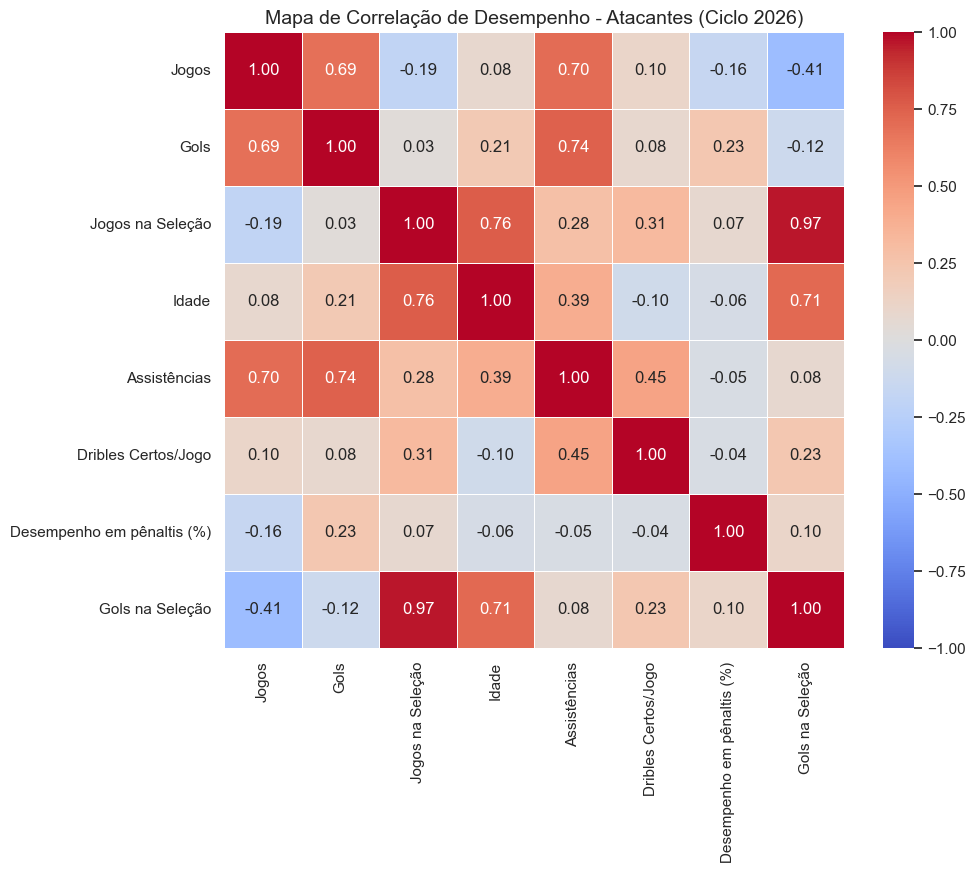

In [8]:
# 1. Definir o tamanho do gráfico
plt.figure(figsize=(10, 8))

# 2. Usar a variável df_atacantes em vez da df_todos. Isto vai buscar os Gols, Jogos, Assistências e Idade dos atacantes
dados_numericos_atacantes = df_atacantes.select_dtypes(include='number')

# 3. Calcular a matriz de correlação matemática
correlacao = dados_numericos_atacantes.corr()

# 4. Desenhar o Mapa de Calor
sns.heatmap(correlacao, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)

# 5. Adicionar o título
plt.title('Mapa de Correlação de Desempenho - Atacantes (Ciclo 2026)', fontsize=14)

# 6. Exibir o gráfico
plt.show()

### 5.1 Correlação de Desempenho Defensivo (Zagueiros)
Para equilibrar nossa análise e entender o comportamento defensivo, investigamos a seguinte hipótese: **Zagueiros que participam de mais ações defensivas ativas (Interceptações + Divididas) tendem a fazer mais faltas?**

Para isso, criamos uma variável combinada e aplicamos o cálculo da **Correlação de Pearson**, ilustrado pelo gráfico de dispersão com linha de tendência abaixo.

Coeficiente de Correlação de Pearson: 0.5902


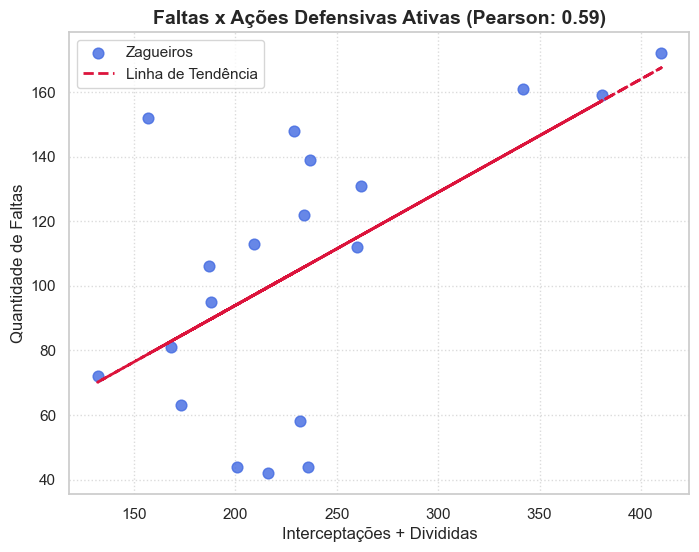

In [9]:
# === CORRELAÇÃO DE PEARSON: Ações Defensivas x Faltas (Zagueiros) ===

# Criando a variável combinada
df_zagueiro['Defensivas_Ativas'] = df_zagueiro['Interceptações'] + df_zagueiro['Divididas']

# Definindo X e Y
x = df_zagueiro['Defensivas_Ativas'].values
y = df_zagueiro['Faltas'].values

# Correlação de Pearson
correlacao = np.corrcoef(x, y)[0, 1]
print(f'Coeficiente de Correlação de Pearson: {correlacao:.4f}')

# Linha de regressão (Linha de tendência)
coef = np.polyfit(x, y, 1)
reta = np.poly1d(coef)

# Configurando o gráfico
plt.figure(figsize=(8, 6))

# Plot dos pontos e da linha
plt.scatter(x, y, color='royalblue', alpha=0.8, s=60, label='Zagueiros')
plt.plot(x, reta(x), color='crimson', linestyle='--', linewidth=2, label='Linha de Tendência')

# Títulos e rótulos
plt.title(f'Faltas x Ações Defensivas Ativas (Pearson: {correlacao:.2f})', fontsize=14, fontweight='bold')
plt.xlabel('Interceptações + Divididas', fontsize=12)
plt.ylabel('Quantidade de Faltas', fontsize=12)

# Estética
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

## 6. Conclusão: O Índice de Desempenho e Critérios de Convocação (2026)

Para responder à nossa pergunta principal e definir os convocados para a Copa do Mundo de 2026 de forma 100% analítica, desenvolvemos um **Índice de Desempenho (Z-Score)**. 

Aplicamos a técnica de padronização (`StandardScaler`) para colocar todas as métricas em uma mesma escala (média 0 e desvio padrão 1), o que nos permitiu somar virtudes e subtrair defeitos de cada jogador. 

Nossos critérios estatísticos para a convocação ideal são:

* **Critério Fundamental (Veteranos x Promessas):** Independentemente da posição, o algoritmo exige que o topo da lista de convocados contenha **pelo menos um jogador classificado como "Experiente"** (Top 10/20% em convocações prévias), garantindo a estabilidade emocional do elenco.

* **Zagueiros e Laterais:** O índice prioriza a solidez. Zagueiros são premiados por um alto volume de **Ações Defensivas, Interceptações e Divididas**, mas sofrem forte **penalização matemática pelas Faltas** cometidas. Para os laterais, o fator **Cruzamento** atua como um bônus essencial na saída de bola.

* **Meio-Campistas (VOL, MC, MEI):** Buscamos os "motores" do time. O índice mede a versatilidade absoluta: o jogador perfeito precisa ter números altos na destruição de jogadas (**Divididas Certas e Interceptações**) e na criação ofensiva (**Assistências e Cruzamentos**), também sendo penalizado pelo excesso de faltas.

* **Atacantes:** A métrica é voltada à eficiência e quebra de linhas. O topo do nosso ranking destaca os jogadores com os melhores scores combinados de **Gols, Assistências e Dribles Certos por Jogo**. Adicionamos a **Taxa de Conversão de Pênaltis** como critério de desempate crucial para o mata-mata.

* **Goleiros:** A confiança foi medida quantitativamente. O índice prioriza goleiros com a maior taxa de **Jogos sem sofrer gols (Clean Sheets)** em relação às **Defesas por Jogo**, com um bônus direto para a quantidade de **Pênaltis Agarrados**.

**Resultado Final:** Com este Índice de Desempenho, o Grupo 9 substitui o "achismo" tático por uma ferramenta estatística robusta, capaz de elencar os melhores jogadores brasileiros em atividade de forma justa, equilibrada e focada em resultados reais.

### 6.1 Índice de Desempenho: Defesa (Zagueiros e Laterais)
Para a linha defensiva, nosso índice premia o volume de jogo (Divididas, Interceptações e Ações Defensivas) e a capacidade de apoio (Cruzamentos). Em contrapartida, penalizamos matematicamente as **Faltas**, pois defensores faltosos geram perigo de gol ao adversário. A padronização **Z-Score** foi aplicada para colocar todas essas grandezas em uma escala única.

In [10]:
# === ÍNDICE DE DESEMPENHO: ZAGUEIROS E LATERAIS ===
from sklearn.preprocessing import StandardScaler

# 1. Padronizar nomes das colunas e transformar texto da Posição em minúsculas para facilitar o filtro
df_zagueiro.columns = df_zagueiro.columns.str.strip()
df_zagueiro['Posição'] = df_zagueiro['Posição'].str.strip().str.lower()

# 2. Seleção das métricas que importam para a defesa
colunas_defesa = ['Divididas', 'Faltas', 'Interceptações', 'Cruzamentos', 'Ações Defensivas']

# 3. Padronização (Z-SCORE)
scaler = StandardScaler()
df_zagueiro[colunas_defesa] = scaler.fit_transform(df_zagueiro[colunas_defesa])

# 4. Criação do Índice de Desempenho (Média das métricas padronizadas)
df_zagueiro['Indice_Desempenho'] = np.mean([
    df_zagueiro['Divididas'],
    df_zagueiro['Interceptações'],
    df_zagueiro['Cruzamentos'],
    -df_zagueiro['Faltas'],  # O sinal de MENOS aplica a penalização pelas faltas!
    df_zagueiro['Ações Defensivas']
], axis=0)

# 5. Ordenação Geral (do melhor para o pior)
df_ordenado_defesa = df_zagueiro.sort_values(by='Indice_Desempenho', ascending=False)

# 6. Separação por Posição Específica
df_zagueiros_puros = df_ordenado_defesa[df_ordenado_defesa['Posição'].str.contains('zagueiro')]
df_laterais_puros = df_ordenado_defesa[df_ordenado_defesa['Posição'].str.contains('lateral')]

# 7. Exibição dos Rankings
print("=== RANKING FINAL: ZAGUEIROS ===")
display(df_zagueiros_puros[['Jogador', 'Posição', 'Indice_Desempenho', 'Experiente']].head(8))

print("\n=== RANKING FINAL: LATERAIS ===")
display(df_laterais_puros[['Jogador', 'Posição', 'Indice_Desempenho', 'Experiente']].head(5))

=== RANKING FINAL: ZAGUEIROS ===


,Jogador,Posição,Indice_Desempenho,Experiente
7,Roger Ibañez,zagueiro,0.821881,Não
8,Danilo,zagueiro/lateral,0.034358,Sim
0,Marquinhos,zagueiro,-0.145535,Sim
1,Gabriel Magalhães,zagueiro,-0.245611,Não
5,Bremer,zagueiro,-0.356409,Não
6,Léo Pereira,zagueiro,-0.416050,Não
3,Fabrício Bruno,zagueiro,-0.466556,Não
2,Éder Militão,zagueiro / lateral,-0.504075,Sim



=== RANKING FINAL: LATERAIS ===


,Jogador,Posição,Indice_Desempenho,Experiente
13,Vanderson,lateral,1.043830,Não
12,Wesley,lateral,0.780096,Não
11,Douglas Santos,lateral,0.558283,Não
10,Caio Henrique,lateral,0.541964,Não
14,Paulo Henrique,lateral,0.231112,Não


### 6.2 Índice de Desempenho: Meio-Campo (Volantes e Meias)
O setor de meio-campo exige atletas híbridos. Nosso índice premia o jogador que consegue defender bem (**Divididas Certas e Interceptações**) e criar jogadas ofensivas com eficiência (**Assistências e Cruzamentos**). Novamente, o excesso de **Faltas** foi colocado como um peso negativo na balança matemática do Z-Score para punir jogadores indisciplinados.

In [11]:
# === ÍNDICE DE DESEMPENHO: MEIO-CAMPISTAS ===

# 1. Limpeza e padronização (transformando a Posição em MAIÚSCULAS para os filtros)
df_meio.columns = df_meio.columns.str.strip()
df_meio['Posição'] = df_meio['Posição'].str.strip().str.upper()

# 2. Selecionando as colunas exatas
colunas_meio = ['Faltas', 'Divididas Certas', 'Assistências', 'Cruzamentos', 'Interceptações']

# 3. Padronização (Z-SCORE) - Aplicando em todas as colunas de uma vez (Evita o erro de 1D Array!)
scaler_meio = StandardScaler()
df_meio[colunas_meio] = scaler_meio.fit_transform(df_meio[colunas_meio])

# 4. Criação do Índice de Desempenho
df_meio['Indice_Desempenho'] = np.mean([
    -df_meio['Faltas'],           # Penalização
    df_meio['Divididas Certas'],  # Bônus Defensivo
    df_meio['Assistências'],      # Bônus Ofensivo
    df_meio['Cruzamentos'],       # Bônus Ofensivo
    df_meio['Interceptações']     # Bônus Defensivo
], axis=0)

# 5. Ordenação Geral
df_ordenado_meio = df_meio.sort_values(by='Indice_Desempenho', ascending=False)

# 6. Separação por tipo de Meia (Volante, Meia Central, Meia Ofensivo)
df_vol = df_ordenado_meio[df_ordenado_meio['Posição'].str.contains('VOL')]
df_mc = df_ordenado_meio[df_ordenado_meio['Posição'].str.contains('MC')]
df_mei = df_ordenado_meio[df_ordenado_meio['Posição'].str.contains('MEI')]

# 7. Exibição dos Rankings
print("=== RANKING FINAL: VOLANTES (VOL) ===")
display(df_vol[['Jogador', 'Posição', 'Indice_Desempenho', 'Experiente']].head(5))

print("\n=== RANKING FINAL: MEIAS CENTRAIS (MC) ===")
display(df_mc[['Jogador', 'Posição', 'Indice_Desempenho', 'Experiente']].head(5))

print("\n=== RANKING FINAL: MEIAS OFENSIVOS (MEI) ===")
display(df_mei[['Jogador', 'Posição', 'Indice_Desempenho', 'Experiente']].head(5))

=== RANKING FINAL: VOLANTES (VOL) ===


,Jogador,Posição,Indice_Desempenho,Experiente
1,Casemiro,VOL,0.068785,Sim
7,João Gomes,VOL,-0.131824,Não
3,Fabinho,VOL,-0.134616,Não
8,Jean Lucas,VOL,-0.327009,Não



=== RANKING FINAL: MEIAS CENTRAIS (MC) ===


,Jogador,Posição,Indice_Desempenho,Experiente
5,Bruno Guimarães,MC,0.318876,Sim
9,Joelinton,MC,0.176245,Não
10,Gerson,MC,0.099746,Não
2,Danilo Oliveira,MC,-0.236939,Não
0,Andrey Santos,MC,-0.823721,Não



=== RANKING FINAL: MEIAS OFENSIVOS (MEI) ===


,Jogador,Posição,Indice_Desempenho,Experiente
4,Gabriel Sara,MEI,0.444069,Não
11,Andreas Pereira,MEI,0.376729,Não
6,Lucas Paquetá,MEI,0.169660,Sim


### 6.3 Índice de Desempenho: Atacantes
Para o setor ofensivo, nosso Z-Score é focado 100% em produtividade. O algoritmo busca o atacante mais decisivo, criando um ranking baseado no volume de **Gols, Assistências e Dribles Certos por Jogo**. Adicionamos a **Taxa de Conversão de Pênaltis** como métrica auxiliar para cenários de mata-mata.

In [12]:
# === ÍNDICE DE DESEMPENHO: ATACANTES ===

# 1. Padronização das colunas
df_atacantes.columns = df_atacantes.columns.str.strip()

# 2. Seleção das métricas (todas são positivas, quanto maior, melhor)
colunas_ata = ['Gols', 'Assistências', 'Dribles Certos/Jogo', 'Desempenho em pênaltis (%)']

# 3. Padronização (Z-SCORE)
scaler_ata = StandardScaler()
df_atacantes[colunas_ata] = scaler_ata.fit_transform(df_atacantes[colunas_ata])

# 4. Criação do Índice de Desempenho
df_atacantes['Indice_Desempenho'] = np.mean([
    df_atacantes['Gols'],
    df_atacantes['Assistências'],
    df_atacantes['Dribles Certos/Jogo'],
    df_atacantes['Desempenho em pênaltis (%)']
], axis=0)

# 5. Ordenação Geral (do melhor para o pior)
df_ordenado_ata = df_atacantes.sort_values(by='Indice_Desempenho', ascending=False)

# 6. Exibição do Ranking
print("=== RANKING FINAL: ATACANTES ===")
display(df_ordenado_ata[['Jogador', 'Posição', 'Indice_Desempenho', 'Experiente']].head(8))

=== RANKING FINAL: ATACANTES ===


,Jogador,Posição,Indice_Desempenho,Experiente
8,Vinicius Junior,Ponta Esquerdo,1.672239,Não
6,Raphinha,Ponta Esquerdo,0.995066,Não
3,João Pedro,Centroavante,0.406088,Não
9,Neymar,Ponta Esquerdo,0.228109,Sim
13,Antony,Ponta Direito,0.224346,Não
11,Estevão,Ponta Direito,0.210717,Não
1,G. Martinelli,Ponta Esquerdo,0.029796,Não
5,Matheus Cunha,Centroavante,-0.125353,Não


### 6.4 Índice de Desempenho: Goleiros
A escolha do goleiro exige frieza nos números. O índice padronizado busca o equilíbrio entre consistência (**Jogos sem sofrer gol**) e capacidade de reação (**Defesas por jogo**), somado ao bônus de **Pênaltis agarrados**.

In [14]:
# === ÍNDICE DE DESEMPENHO: GOLEIROS ===

# 1. Padronização das colunas
df_goleiros.columns = df_goleiros.columns.str.strip()

# 1.1 GARANTINDO A COLUNA POSIÇÃO (Para não dar erro na exibição final)
df_goleiros['Posição'] = 'Goleiro'

# 1.5 GARANTINDO A COLUNA EXPERIENTE (Top 10%)
percentil_gol = df_goleiros['Jogos na Seleção'].quantile(0.9)
df_goleiros['Experiente'] = np.where(df_goleiros['Jogos na Seleção'] > percentil_gol, 'Sim', 'Não')

# 2. Seleção das métricas
colunas_gol = ['Jogos sem sofrer gol', 'Defesas/Jogo', 'Pênaltis agarrados']

# 3. Padronização (Z-SCORE)
scaler_gol = StandardScaler()
df_goleiros[colunas_gol] = scaler_gol.fit_transform(df_goleiros[colunas_gol])

# 4. Criação do Índice de Desempenho
df_goleiros['Indice_Desempenho'] = np.mean([
    df_goleiros['Jogos sem sofrer gol'],
    df_goleiros['Defesas/Jogo'],
    df_goleiros['Pênaltis agarrados']
], axis=0)

# 5. Ordenação Geral
df_ordenado_gol = df_goleiros.sort_values(by='Indice_Desempenho', ascending=False)

# 6. Exibição do Ranking
print("=== RANKING FINAL: GOLEIROS ===")
display(df_ordenado_gol[['Jogador', 'Posição', 'Indice_Desempenho', 'Experiente']].head(4))

=== RANKING FINAL: GOLEIROS ===


,Jogador,Posição,Indice_Desempenho,Experiente
0,Hugo Souza,Goleiro,0.488059,Não
3,Alisson,Goleiro,0.113392,Sim
1,Bento,Goleiro,-0.272530,Não
2,Ederson,Goleiro,-0.328921,Não


---

## 7. A Lista Final de Convocados (Copa do Mundo 2026)

Com base em toda a nossa análise exploratória e na aplicação do Índice de Desempenho (Z-Score), definimos uma estrutura de elenco equilibrada para a competição. 

Decidimos o seguinte modelo de convocação (totalizando 26 atletas):
* **3 Goleiros**
* **9 Defensores** (5 zagueiros e 4 laterais)
* **5 Meio-campistas** (2 Volantes, 2 Meias Centrais e 1 Meia Ofensivo)
* **9 Atacantes**

Por fim, cruzando os dados quantitativos com os critérios de experiência e desempenho por setor, concluímos que os seguintes jogadores formam o elenco ideal para representar a Seleção Brasileira:

### 🧤 Goleiros
**Hugo Souza, Alisson e Bento**

### 🛡️ Defensores
**Roger Ibañez, Danilo, Marquinhos, Gabriel Magalhães, Bremer, Vanderson, Wesley, Douglas Santos e Caio Henrique**

### 🧠 Meio-Campistas
**Bruno Guimarães, Joelinton, Casemiro, João Gomes e Gabriel Sara**

### ⚽ Atacantes
**Vinicius Júnior, Raphinha, João Pedro, Neymar, Antony, Estêvão, G. Martinelli, Matheus Cunha e Igor Thiago**

---